# Pet Insurance Claims Risk Analytics

## Dataset Source
Allstate Claims Severity (Kaggle)

## Project Objective
Adapt a real-world insurance claims dataset into a simulated pet insurance portfolio and analyse claim severity drivers, risk segmentation and pricing implications.

## Current Stage
Dataset exploration and pet insurance schema design.

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/raw/train.csv")

df = df.rename(columns={
    "loss": "claim_amount"
})

df.head()

,id,cat1,cat2,cat3,cat4,cat5,cat6,cat7,cat8,cat9,...,cont6,cont7,cont8,cont9,cont10,cont11,cont12,cont13,cont14,claim_amount
0,1,A,B,A,B,A,A,A,A,B,...,0.718367,0.335060,0.30260,0.67135,0.83510,0.569745,0.594646,0.822493,0.714843,2213.18
1,2,A,B,A,A,A,A,A,A,B,...,0.438917,0.436585,0.60087,0.35127,0.43919,0.338312,0.366307,0.611431,0.304496,1283.60
2,5,A,B,A,A,B,A,A,A,B,...,0.289648,0.315545,0.27320,0.26076,0.32446,0.381398,0.373424,0.195709,0.774425,3005.09
3,10,B,B,A,B,A,A,A,A,B,...,0.440945,0.391128,0.31796,0.32128,0.44467,0.327915,0.321570,0.605077,0.602642,939.85
4,11,A,B,A,B,A,A,A,A,B,...,0.178193,0.247408,0.24564,0.22089,0.21230,0.204687,0.202213,0.246011,0.432606,2763.85


## Create Species Variable

### Business Assumption

Pet insurance policies in Australia are predominantly held by dog owners.

### Assumed Distribution

- Dogs: 80%
- Cats: 20%

### Method

Random assignment using NumPy probability sampling.


In [2]:
np.random.seed(42)

df["species"] = np.random.choice(
    ["Dog", "Cat"],
    size=len(df),
    p=[0.8, 0.2]
)

df["species"].value_counts()

Dog    150568
Cat     37750
Name: species, dtype: int64

### Validation

Distribution checked using value_counts(normalize=True).

In [3]:
df["species"].value_counts(normalize=True)

Dog    0.799541
Cat    0.200459
Name: species, dtype: float64

## Create Breed Variable

Assumption:

Dogs:
- Kelpie
- Labrador
- Golden Retriever
- Border Collie
- German Shepherd
- French Bulldog
- Dachshund

Cats:
- Domestic Shorthair
- Ragdoll
- Siamese
- Persian
- Maine Coon

Rationale:
Breed is one of the most important predictors of claim frequency and claim severity in pet insurance.

In [4]:
dog_breeds = [
    "Kelpie",
    "Labrador",
    "Golden Retriever",
    "Border Collie",
    "German Shepherd",
    "French Bulldog",
    "Dachshund"
]

cat_breeds = [
    "Domestic Shorthair",
    "Ragdoll",
    "Siamese",
    "Persian",
    "Maine Coon"
]

In [5]:
df["breed"] = np.where(
    df["species"] == "Dog",
    np.random.choice(dog_breeds, size=len(df)),
    np.random.choice(cat_breeds, size=len(df))
)

In [10]:
df["breed"].value_counts()

Golden Retriever      21681
German Shepherd       21563
Dachshund             21541
Kelpie                21536
Labrador              21508
French Bulldog        21427
Border Collie         21312
Siamese                7654
Persian                7612
Maine Coon             7529
Ragdoll                7528
Domestic Shorthair     7427
Name: breed, dtype: int64

In [11]:
pd.crosstab(df["species"], df["breed"])

breed,Border Collie,Dachshund,Domestic Shorthair,French Bulldog,German Shepherd,Golden Retriever,Kelpie,Labrador,Maine Coon,Persian,Ragdoll,Siamese
species,,,,,,,,,,,,
Cat,0,0,7427,0,0,0,0,0,7529,7612,7528,7654
Dog,21312,21541,0,21427,21563,21681,21536,21508,0,0,0,0


In [8]:
dog_probs = [
    0.12,  # Kelpie
    0.20,  # Labrador
    0.18,  # Golden Retriever
    0.15,  # Border Collie
    0.15,  # German Shepherd
    0.10,  # French Bulldog
    0.10   # Dachshund
]

In [9]:
np.random.choice(
    dog_breeds,
    size=len(df),
    p=dog_probs
)

array(['Dachshund', 'Border Collie', 'Golden Retriever', ..., 'Kelpie',
       'Kelpie', 'Golden Retriever'], dtype='<U16')

## Create Pet Age Variable

Assumption:
- Most insured pets are young to middle-aged.
- Senior pets are less common.

Rationale:
Pet age is a major predictor of claim frequency and claim severity.

In [20]:
df["pet_age"] = np.random.choice(
    range(0,16),
    size=len(df),
    p=[
        0.08,0.08,0.08,0.08,
        0.08,0.08,0.08,0.08,
        0.07,0.07,0.06,0.05,
        0.04,0.03,0.02,0.02
    ]
)

In [21]:
df["pet_age"].value_counts().sort_index()

0     15159
1     14816
2     15156
3     15020
4     15321
5     15188
6     14906
7     15007
8     13259
9     13137
10    11300
11     9324
12     7587
13     5549
14     3813
15     3776
Name: pet_age, dtype: int64

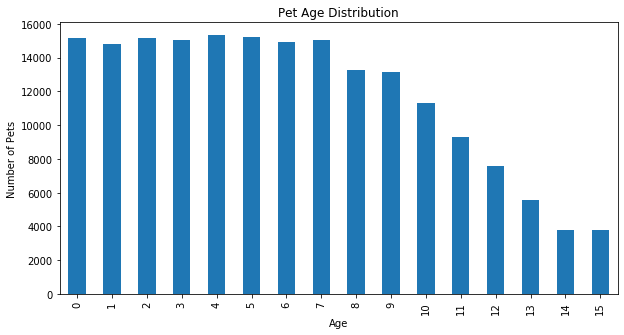

In [22]:
import matplotlib.pyplot as plt

df["pet_age"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Pet Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Pets")
plt.show()

## Create Coverage Level Variable

Assumption:

- Basic: 25%
- Standard: 45%
- Comprehensive: 30%

Rationale:

Coverage level affects claim reimbursement and claim severity.
Comprehensive policies generally result in higher claim costs.

In [23]:
coverage_levels = [
    "Basic",
    "Standard",
    "Comprehensive"
]

coverage_probs = [
    0.25,
    0.45,
    0.30
]

df["coverage_level"] = np.random.choice(
    coverage_levels,
    size=len(df),
    p=coverage_probs
)

In [24]:
df["coverage_level"].value_counts()

Standard         84920
Comprehensive    56322
Basic            47076
Name: coverage_level, dtype: int64

In [25]:
df["coverage_level"].value_counts(normalize=True)

Standard         0.450939
Comprehensive    0.299079
Basic            0.249981
Name: coverage_level, dtype: float64

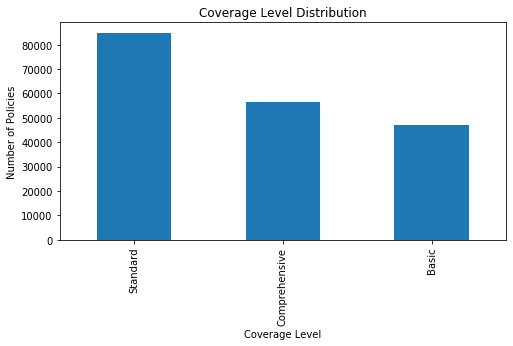

In [26]:
df["coverage_level"].value_counts().plot(
    kind="bar",
    figsize=(8,4)
)

plt.title("Coverage Level Distribution")
plt.xlabel("Coverage Level")
plt.ylabel("Number of Policies")
plt.show()

## Create Excess Variable

Assumption:

- $0 Excess: 20%

- $100 Excess: 40%

- $250 Excess: 30%

- $500 Excess: 10%

Rationale:

Higher excess generally reduces insurer claim costs and increases policyholder cost sharing.

In [27]:
excess_options = [
    0,
    100,
    250,
    500
]

excess_probs = [
    0.20,
    0.40,
    0.30,
    0.10
]

df["excess"] = np.random.choice(
    excess_options,
    size=len(df),
    p=excess_probs
)

In [28]:
df["excess"].value_counts().sort_index()

0      37469
100    75849
250    56074
500    18926
Name: excess, dtype: int64

In [29]:
df["excess"].value_counts(normalize=True).sort_index()

0      0.198967
100    0.402771
250    0.297762
500    0.100500
Name: excess, dtype: float64

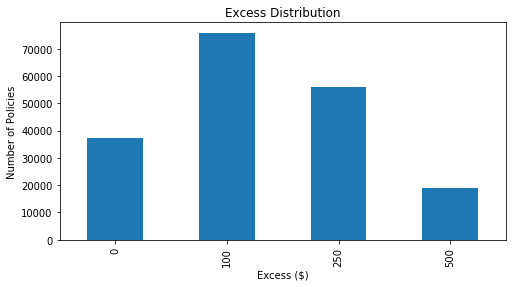

In [30]:
df["excess"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(8,4)
)

plt.title("Excess Distribution")
plt.xlabel("Excess ($)")
plt.ylabel("Number of Policies")
plt.show()

## Create Breed Risk Factor

Assumption:

Different breeds have different claim severity profiles.

Rationale:

Certain breeds are predisposed to hereditary, respiratory or orthopaedic conditions.

In [32]:
breed_risk = {
    "Kelpie": 1.00,
    "Border Collie": 1.00,
    "Labrador": 1.10,
    "Golden Retriever": 1.15,
    "German Shepherd": 1.20,
    "French Bulldog": 1.40,
    "Dachshund": 1.50,
    
    "Domestic Shorthair": 1.00,
    "Ragdoll": 1.05,
    "Siamese": 1.10,
    "Persian": 1.25,
    "Maine Coon": 1.15
}

In [33]:
df["breed_risk_factor"] = df["breed"].map(breed_risk)

In [34]:
df.groupby("breed")["breed_risk_factor"].mean()

breed
Border Collie         1.00
Dachshund             1.50
Domestic Shorthair    1.00
French Bulldog        1.40
German Shepherd       1.20
Golden Retriever      1.15
Kelpie                1.00
Labrador              1.10
Maine Coon            1.15
Persian               1.25
Ragdoll               1.05
Siamese               1.10
Name: breed_risk_factor, dtype: float64

## Create Age Risk Factor

Assumption:

Older pets generally incur higher claim costs.

Rationale:

Claim severity tends to increase with age due to chronic disease and age-related conditions.

In [35]:
def age_factor(age):
    
    if age <= 2:
        return 0.8
    
    elif age <= 6:
        return 1.0
    
    elif age <= 10:
        return 1.3
    
    else:
        return 1.8

In [36]:
df["age_risk_factor"] = df["pet_age"].apply(age_factor)

In [37]:
df.groupby("pet_age")["age_risk_factor"].mean()

pet_age
0     0.8
1     0.8
2     0.8
3     1.0
4     1.0
5     1.0
6     1.0
7     1.3
8     1.3
9     1.3
10    1.3
11    1.8
12    1.8
13    1.8
14    1.8
15    1.8
Name: age_risk_factor, dtype: float64

## Create Coverage Risk Factor

Assumption:

Higher coverage plans generally reimburse a larger proportion of veterinary costs.

Rationale:

Comprehensive policies are expected to result in higher claim severity than Basic policies.

In [38]:
coverage_risk = {
    "Basic": 0.8,
    "Standard": 1.0,
    "Comprehensive": 1.3
}

In [39]:
df["coverage_risk_factor"] = (
    df["coverage_level"]
      .map(coverage_risk)
)

In [40]:
df.groupby("coverage_level")[
    "coverage_risk_factor"
].mean()

coverage_level
Basic            0.8
Comprehensive    1.3
Standard         1.0
Name: coverage_risk_factor, dtype: float64

## Create Excess Risk Factor

Assumption:

Higher excess levels discourage smaller claims and reduce insurer costs.

Rationale:

Policyholders with higher excess are generally expected to generate lower claim severity.

In [41]:
excess_risk = {
    0:   1.20,
    100: 1.00,
    250: 0.90,
    500: 0.75
}

In [42]:
df["excess_risk_factor"] = (
    df["excess"]
      .map(excess_risk)
)

In [43]:
df.groupby("excess")[
    "excess_risk_factor"
].mean()

excess
0      1.20
100    1.00
250    0.90
500    0.75
Name: excess_risk_factor, dtype: float64

## Create Adjusted Claim Amount

Objective:

Incorporate pet insurance business assumptions into claim severity.

Formula:

Adjusted Claim Amount =
Base Claim Amount
× Breed Risk Factor
× Age Risk Factor
× Coverage Risk Factor
× Excess Risk Factor

In [44]:
df["adjusted_claim_amount"] = (
    df["claim_amount"]
    * df["breed_risk_factor"]
    * df["age_risk_factor"]
    * df["coverage_risk_factor"]
    * df["excess_risk_factor"]
)

In [45]:
df[[
    "claim_amount",
    "adjusted_claim_amount"
]].describe()

,claim_amount,adjusted_claim_amount
count,188318.000000,188318.000000
mean,3037.337686,4258.958260
std,2904.086186,4743.450261
min,0.670000,0.836160
25%,1204.460000,1500.467065
50%,2115.570000,2776.266500
75%,3864.045000,5272.306380
max,121012.250000,274455.783000


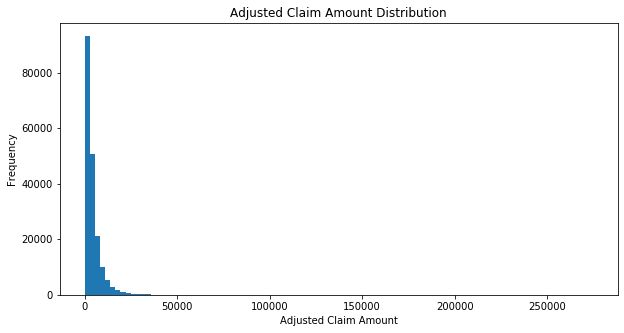

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(
    df["adjusted_claim_amount"],
    bins=100
)

plt.title("Adjusted Claim Amount Distribution")
plt.xlabel("Adjusted Claim Amount")
plt.ylabel("Frequency")

plt.show()

## Claim Severity by Breed

In [47]:
breed_summary = (
    df.groupby("breed")
      ["adjusted_claim_amount"]
      .mean()
      .sort_values(ascending=False)
)

breed_summary

breed
Dachshund             5396.694730
French Bulldog        5122.509056
Persian               4505.893920
German Shepherd       4334.116165
Maine Coon            4182.629702
Golden Retriever      4132.719638
Siamese               3997.565250
Labrador              3943.834875
Ragdoll               3806.500446
Domestic Shorthair    3666.490000
Border Collie         3652.281008
Kelpie                3623.478809
Name: adjusted_claim_amount, dtype: float64

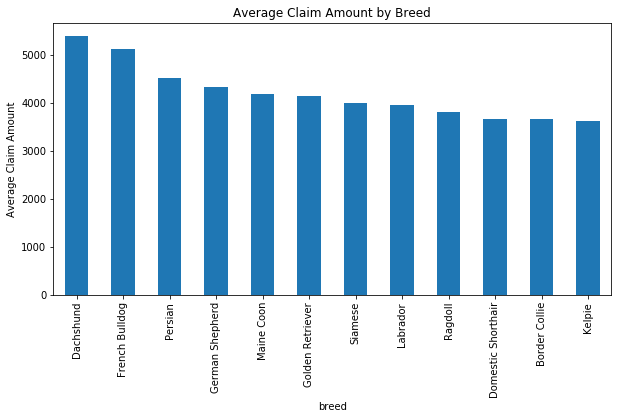

In [48]:
breed_summary.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Average Claim Amount by Breed")
plt.ylabel("Average Claim Amount")
plt.show()

## Claim Severity by Pet Age

In [49]:
age_summary = (
    df.groupby("pet_age")
      ["adjusted_claim_amount"]
      .mean()
)

age_summary

pet_age
0     2899.486829
1     2925.248549
2     2932.114676
3     3689.061521
4     3686.734507
5     3644.816086
6     3695.756045
7     4747.321568
8     4738.759845
9     4718.115040
10    4820.260472
11    6657.326658
12    6576.274358
13    6472.815441
14    6533.808389
15    6525.883135
Name: adjusted_claim_amount, dtype: float64

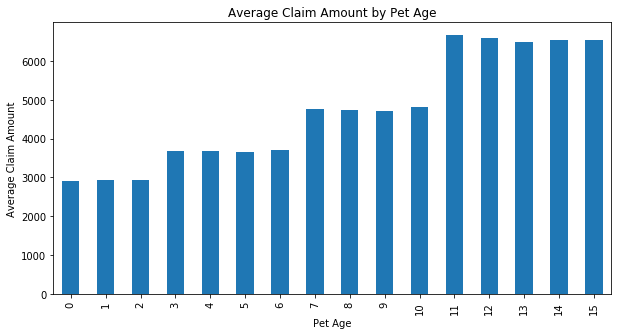

In [50]:
age_summary.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Average Claim Amount by Pet Age")
plt.xlabel("Pet Age")
plt.ylabel("Average Claim Amount")

plt.show()

## Claim Severity by Coverage Level

In [51]:
coverage_summary = (
    df.groupby("coverage_level")
      ["adjusted_claim_amount"]
      .mean()
      .sort_values()
)

coverage_summary

coverage_level
Basic            3286.053410
Standard         4103.037788
Comprehensive    5307.238421
Name: adjusted_claim_amount, dtype: float64

## High Risk Segment Identification

In [52]:
segment_summary = (
    df.groupby([
        "breed",
        "coverage_level"
    ])["adjusted_claim_amount"]
    .mean()
    .sort_values(ascending=False)
)

segment_summary.head(15)

breed               coverage_level
Dachshund           Comprehensive     6709.814611
French Bulldog      Comprehensive     6374.834536
Persian             Comprehensive     5602.714784
German Shepherd     Comprehensive     5372.720775
Maine Coon          Comprehensive     5228.278658
Golden Retriever    Comprehensive     5169.842383
Dachshund           Standard          5165.194936
Labrador            Comprehensive     4914.381490
French Bulldog      Standard          4897.300437
Siamese             Comprehensive     4872.839549
Ragdoll             Comprehensive     4786.894414
Domestic Shorthair  Comprehensive     4611.210453
Border Collie       Comprehensive     4605.792512
Kelpie              Comprehensive     4486.853526
Persian             Standard          4424.530352
Name: adjusted_claim_amount, dtype: float64

In [53]:
portfolio_summary = pd.DataFrame({
    "Policies":[len(df)],
    "Average Claim":[df["adjusted_claim_amount"].mean()],
    "Median Claim":[df["adjusted_claim_amount"].median()],
    "Max Claim":[df["adjusted_claim_amount"].max()]
})

portfolio_summary

,Policies,Average Claim,Median Claim,Max Claim
0,188318,4258.95826,2776.2665,274455.783


In [54]:
species_summary = (
    df.groupby("species")
      ["adjusted_claim_amount"]
      .mean()
)

species_summary

species
Cat    4033.737869
Dog    4315.424905
Name: adjusted_claim_amount, dtype: float64

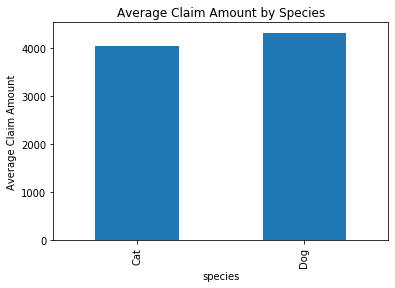

In [55]:
species_summary.plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Average Claim Amount by Species")
plt.ylabel("Average Claim Amount")
plt.show()

# Export Processed Pet Insurance Dataset

In [57]:
import os

print(os.getcwd())
print(os.path.exists("../data"))
print(os.path.exists("../data/processed"))

/Users/liyanjie/Desktop/pet-insurance-claims-risk-analytics/notebooks
True
False


In [58]:
import os

os.makedirs("../data/processed", exist_ok=True)

In [59]:
final_df = df.copy()

final_df.to_csv(
    "../data/processed/pet_insurance_claims.csv",
    index=False
)

print(final_df.shape)

(188318, 142)
